In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import seaborn as sns
from ase import Atoms
from ase.io import read, write
import torch
from itertools import product
import plotly.express as px
import plotly.graph_objects as go
from torch_geometric.utils import dense_to_sparse

import warnings
warnings.filterwarnings("ignore")

In [2]:
from modules.CHILI import CHILI
# Load CHILI dataset
dataset = CHILI(
    root="./data/",
    dataset="CHILI-3K",
    graph_type="",
)

In [3]:
dataset.len()

3180

In [4]:
test_datapoint = dataset.get(2)
test_datapoint

Data(
  x=[1067, 4],
  edge_index=[2, 5244],
  edge_attr=[5244],
  y={
    crystal_type='CadmiumChloride',
    space_group_symbol='R -3 m',
    space_group_number=166,
    crystal_system='Trigonal',
    crystal_system_number=5,
    atomic_species=[2],
    n_atomic_species=2,
    np_size=33.58469009399414,
    n_atoms=1067,
    n_bonds=5244,
    cell_params=[1, 6],
    unit_cell_x=[9, 4],
    unit_cell_edge_index=[2, 12],
    unit_cell_edge_attr=[12],
    unit_cell_pos_abs=[9, 3],
    unit_cell_pos_frac=[9, 3],
    unit_cell_n_atoms=9,
    unit_cell_n_bonds=12,
    nd=[1, 2, 580],
    xrd=[1, 2, 580],
    nPDF=[1, 2, 6000],
    xPDF=[1, 2, 6000],
    sans=[1, 2, 300],
    saxs=[1, 2, 300],
  },
  data_id='',
  pos_abs=[1067, 3],
  pos_frac=[1067, 3]
)

In [ ]:
test_datapoint.y['atomic_species']

tensor([ 8., 72.])

In [6]:
# from ase import Atoms
# from ase.visualize import view

# atom_test = Atoms(symbols=test_datapoint.y['unit_cell_x'][:, 0], scaled_positions=test_datapoint.y['unit_cell_pos_frac'], cell=test_datapoint.y['cell_params'].squeeze())
# atom_test_2 = Atoms(symbols=test_datapoint.x[:, 0], positions=test_datapoint.pos_abs, cell=test_datapoint.y['cell_params'].squeeze())

In [7]:
# print(test_datapoint.y['unit_cell_x'][:, 0])
# print(test_datapoint.y['unit_cell_pos_frac'])
# print(test_datapoint.y['unit_cell_edge_index'])

In [8]:
# test_datapoint.y['cell_params'].squeeze()[:3].amax()

In [9]:
# # First expand unit cell to make it as square as possible
# # Then expand the square cell to have more than 56 atoms
# # Then select the 56 atoms that are closest to 0, 0, 0
# test_datapoint.y['cell_params'].squeeze()[:3]

# max_cell_atoms = 56
# cell_dim_ratio = test_datapoint.y['cell_params'].squeeze()[:3].amax() // test_datapoint.y['cell_params'].squeeze()[:3]

# n_unit_cell_atoms = len(test_datapoint.y['unit_cell_x'])
# n_super_cell_atoms = n_unit_cell_atoms * cell_dim_ratio.prod().long()
# print(n_unit_cell_atoms, n_super_cell_atoms)
# print(max_cell_atoms // n_unit_cell_atoms)
# print(max_cell_atoms // n_super_cell_atoms)
# pri
# # print(tuple(cell_dim_ratio.long().tolist()))

# # Calculate the needed expansion of the unit cell
# cell_translations = torch.stack(torch.where(torch.zeros(tuple(cell_dim_ratio.long().tolist())) == 0), dim=1)
# # print(cell_translation)

# edge_number = len(test_datapoint.y['unit_cell_edge_index'])

# cell_frac_positions = []
# cell_node_features = []
# for cell_translation in cell_translations:
#     cell_frac_positions.extend(test_datapoint.y['unit_cell_pos_frac'] + torch.tensor(cell_translation))
#     cell_node_features.extend(test_datapoint.y['unit_cell_x'])
    

# cell_frac_positions = torch.stack(cell_frac_positions)
# cell_node_features = torch.stack(cell_node_features)

# atom_test_3 = Atoms(symbols=cell_node_features[:, 0], scaled_positions=cell_frac_positions, cell=test_datapoint.y['cell_params'].squeeze())

# # Select the 56 atoms that are closest to 0, 0, 0
# distances = torch.norm(cell_frac_positions, dim=1)


In [10]:
# dists = torch.cdist() #atom_test_3.get_all_distances(mic=True)
# dists = torch.tensor(dists)
# # dists[dists in cell_edge_features.unique()] = 0

In [11]:
# bond_mask = torch.zeros_like(dists)
# for bond_length in cell_edge_features.unique():
#     bond_mask[(dists > bond_length * 0.9) & (dists < bond_length * 1.1)] = 1

In [12]:
# cell_edge_features.unique()

In [13]:
# masked_dists = dists * bond_mask

In [14]:
# new_edge_index, new_edge_features = dense_to_sparse(masked_dists)
# new_edge_features = dists[bond_mask == 1]

In [15]:
# # Plot the unit cell graph using plotly

# fig = go.Figure(data=[
#     # Plotting atoms
#     go.Scatter3d(
#         x=test_datapoint.y['unit_cell_pos_frac'][:, 0],
#         y=test_datapoint.y['unit_cell_pos_frac'][:, 1],
#         z=test_datapoint.y['unit_cell_pos_frac'][:, 2],
#         mode='markers',
#         marker=dict(
#             size=12,
#             color=test_datapoint.y['unit_cell_x'][:, 0],                # set color to an array/list of desired values
#             colorscale='viridis',   # choose a colorscale
#             opacity=1
#         )
#     ),
# ])
# # Plot bonds between atoms as individual lines
# for edge in test_datapoint.y['unit_cell_edge_index'].T:
#     fig.add_trace(go.Scatter3d(
#         x=test_datapoint.y['unit_cell_pos_frac'][edge, 0],
#         y=test_datapoint.y['unit_cell_pos_frac'][edge, 1],
#         z=test_datapoint.y['unit_cell_pos_frac'][edge, 2],
#         mode='lines',
#         line=dict(
#             width=6,
#             color='darkblue'
#         )
#     ))
# fig.update_layout(scene=dict(aspectmode="cube"))
# fig.show()

In [16]:
# print(test_datapoint.y['unit_cell_edge_index'].t())
# print(test_datapoint.y['unit_cell_pos_frac'])

In [17]:
# # Plot the unit cell graph using plotly

# fig = go.Figure(data=[
#     # Plotting atoms
#     go.Scatter3d(
#         x=cell_frac_positions[:, 0],
#         y=cell_frac_positions[:, 1],
#         z=cell_frac_positions[:, 2],
#         mode='markers',
#         marker=dict(
#             size=12,
#             color=cell_node_features[:, 0],                # set color to an array/list of desired values
#             colorscale='viridis',   # choose a colorscale
#             opacity=1
#         )
#     ),
# ])
# # Plot bonds between atoms as individual lines
# for edge in new_edge_index.T:
#     fig.add_trace(go.Scatter3d(
#         x=cell_frac_positions[edge, 0],
#         y=cell_frac_positions[edge, 1],
#         z=cell_frac_positions[edge, 2],
#         mode='lines',
#         line=dict(
#             width=6,
#             color='darkblue'
#         )
#     ))
# fig.update_layout(scene=dict(aspectmode='cube'))
# fig.show()

In [18]:
# atom_test.get_scaled_positions()

In [19]:
# atom_test_2.get_scaled_positions()


In [20]:
# atom_test_3.get_scaled_positions()

In [21]:
# view(atom_test, viewer='x3d')

In [22]:
# view(atom_test_2, viewer='x3d')

In [23]:
# view(atom_test_3, viewer='x3d')

In [24]:
parent_dir = './models'
experiment_name = '6d_split_ls_super_cell_bigPrior_smallEncoder'
json_folder = 'CrystalTypeAnalysis'
json_dir = f'{parent_dir}/{experiment_name}/{json_folder}'
loss_file = f'{parent_dir}/{experiment_name}/{json_folder}/losses.json'
reconstruction_file = f'{parent_dir}/{experiment_name}/{json_folder}/reconstructions.json'


In [25]:
# Read json files and make them into dataframes
with open(loss_file, 'r') as f:
    losses = json.load(f)
df_loss = pd.DataFrame(losses)

with open(reconstruction_file, 'r') as f:
    reconstructions = json.load(f)
df_rec = pd.DataFrame(reconstructions)

In [26]:
df_loss.head()

,total,reconstruction_loss,cell_parameters,cell_positions,cell_atoms,kld,crystalType,particleSize
0,-10.816151,0.000019,0.000008,0.000011,6.386212e-09,0.120656,RheniumTrioxide,11.694150
1,-9.306877,0.000026,0.000005,0.000021,5.534714e-08,2.505565,Wurtzite,23.968201
2,-9.090709,0.000036,0.000010,0.000027,2.128737e-09,2.256765,CaesiumChloride,14.847806
3,-11.055639,0.000015,0.000005,0.000010,6.386212e-09,0.148755,RheniumTrioxide,53.604038
4,-11.071687,0.000014,0.000002,0.000013,1.064368e-08,0.149003,RheniumTrioxide,11.700600


In [ ]:
df_rec.head()

,crystalType,n_atoms,n_oxygens,n_metals,cell_parameters,cell_positions,cell_atoms,latent_space_mean,latent_space_std
0,RheniumTrioxide,56,36,20,"[3.9006996154785156, 3.899207353591919, 3.9189...","[[0.0013599999947473407, -0.000410000007832422...","[2, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 2, 2, ...","[-0.7319613099098206, -0.38860875368118286, 1....","[0.0164794959127903, 0.0649934634566307, 0.033..."
1,Wurtzite,56,25,31,"[3.6797051429748535, 3.6779069900512695, 5.965...","[[0.33351999521255493, 0.6715099811553955, 0.0...","[2, 1, 2, 1, 2, 2, 1, 1, 2, 2, 2, 1, 1, 2, 2, ...","[-2.5387351512908936, -0.35239410400390625, -1...","[0.013988411985337734, 0.07176950573921204, 0...."
2,CaesiumChloride,56,20,36,"[3.3993282318115234, 3.3981285095214844, 3.417...","[[0.007849999703466892, -0.0005799999926239252...","[2, 1, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2, 2, 2, ...","[1.1092486381530762, -0.3341302275657654, -5.1...","[0.023261884227395058, 0.07647174596786499, 0...."
3,RheniumTrioxide,56,36,20,"[3.904874563217163, 3.904733896255493, 3.90624...","[[0.0012799999676644802, -0.000250000011874362...","[2, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 2, 2, ...","[-0.7300553321838379, -0.38872843980789185, 1....","[0.016256794333457947, 0.06488342583179474, 0...."
4,RheniumTrioxide,56,36,20,"[3.9015092849731445, 3.900827407836914, 3.8935...","[[0.003640000009909272, 0.0031300000846385956,...","[2, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 2, 2, ...","[-0.7285502552986145, -0.3903347849845886, 1.1...","[0.016488132998347282, 0.06489166617393494, 0...."


In [28]:
# # Make a cif file from all the reconstructions
# for crystal_type in df_rec['crystalType'].unique():
#     print(crystal_type)
#     df_crystal = df_rec[df_rec['crystalType'] == crystal_type]
#     cell_pos = []
#     cell_atom = []
#     for i, row in df_crystal.iterrows():
#         if i == 0:
#             cell_params=row['cell_parameters']
#         cell_pos.extend(row['cell_positions'])
#         cell_atom.extend(row['cell_atoms'])
#     atoms = Atoms(cell_atom, positions=cell_pos, cell=cell_params)
#     write(f'{parent_dir}/{experiment_name}/{json_folder}/{crystal_type}.cif', atoms)

In [29]:
# Calculate the mean and std of the losses for each crystalType
df_loss_mean = df_loss.groupby('crystalType').mean()
df_loss_std = df_loss.groupby('crystalType').std()

# Calculate the mean and std of n_atoms, n_oxygens and n_metals for each crystalType
df_rec_mean = df_rec[['n_atoms', 'n_oxygens', 'n_metals', 'crystalType']].groupby('crystalType').mean()
df_rec_std = df_rec[['n_atoms', 'n_oxygens', 'n_metals', 'crystalType']].groupby('crystalType').std()

In [30]:
df_combined = pd.concat([df_rec[['n_atoms', 'n_oxygens', 'n_metals', 'crystalType']], df_loss[['total']]], axis=1)
df_combined.head()

,n_atoms,n_oxygens,n_metals,crystalType,total
0,56,36,20,RheniumTrioxide,-10.816151
1,56,25,31,Wurtzite,-9.306877
2,56,20,36,CaesiumChloride,-9.090709
3,56,36,20,RheniumTrioxide,-11.055639
4,56,36,20,RheniumTrioxide,-11.071687


In [31]:
# Show the mean of the losses for each crystalType
df_loss_mean

,total,reconstruction_loss,cell_parameters,cell_positions,cell_atoms,kld,particleSize
crystalType,,,,,,,
AntiFluorite,-8.007515,0.000032,0.000010,0.000021,0.000000e+00,4.823866,35.909263
CadmiumChloride,-9.110443,0.000081,0.000033,0.000047,0.000000e+00,0.697076,34.222034
CadmiumIodide,-8.524152,0.000052,0.000014,0.000038,1.892211e-09,2.761688,35.249483
CaesiumChloride,-9.552718,0.000042,0.000013,0.000029,1.473741e-09,1.120090,32.423777
Fluorite,-10.303408,0.000027,0.000007,0.000020,0.000000e+00,0.602143,38.427455
NickelArsenide,-9.818481,0.000044,0.000019,0.000025,0.000000e+00,0.666865,32.167139
RheniumTrioxide,-10.985365,0.000014,0.000006,0.000008,7.450580e-09,0.496567,29.450815
RockSalt,-9.729628,0.000043,0.000012,0.000031,5.567466e-09,0.955570,30.377289
Rutile,0.093609,0.002886,0.000039,0.002847,4.572830e-09,19.318420,31.665043


In [32]:
# Show the std of the losses for each crystalType
df_loss_std

,total,reconstruction_loss,cell_parameters,cell_positions,cell_atoms,kld,particleSize
crystalType,,,,,,,
AntiFluorite,8.960817,0.000012,0.000009,0.000005,0.000000e+00,17.735196,14.874402
CadmiumChloride,0.812412,0.000022,0.000019,0.000009,0.000000e+00,1.440589,15.957425
CadmiumIodide,3.255491,0.000017,0.000015,0.000009,6.817415e-10,6.470885,14.103034
CaesiumChloride,0.700026,0.000011,0.000010,0.000005,1.001951e-09,1.096779,16.490222
Fluorite,0.513343,0.000013,0.000006,0.000009,0.000000e+00,0.642099,13.897901
NickelArsenide,0.735479,0.000026,0.000025,0.000005,0.000000e+00,0.733079,14.746869
RheniumTrioxide,0.827995,0.000007,0.000006,0.000002,2.427133e-09,1.474566,14.866522
RockSalt,0.833600,0.000026,0.000013,0.000019,2.092402e-09,0.802388,15.779794
Rutile,44.893487,0.012660,0.000088,0.012581,2.124390e-08,89.285122,13.927272


In [33]:
df_rec_mean

,n_atoms,n_oxygens,n_metals
crystalType,,,
AntiFluorite,56.0,26.0,30.0
CadmiumChloride,56.0,37.0,19.0
CadmiumIodide,56.0,30.0,26.0
CaesiumChloride,56.0,20.0,36.0
Fluorite,56.0,30.0,26.0
NickelArsenide,56.0,18.0,38.0
RheniumTrioxide,56.0,36.0,20.0
RockSalt,56.0,27.0,29.0
Rutile,56.0,32.0,24.0


In [34]:
df_rec_std

,n_atoms,n_oxygens,n_metals
crystalType,,,
AntiFluorite,0.0,0.0,0.0
CadmiumChloride,0.0,0.0,0.0
CadmiumIodide,0.0,0.0,0.0
CaesiumChloride,0.0,0.0,0.0
Fluorite,0.0,0.0,0.0
NickelArsenide,0.0,0.0,0.0
RheniumTrioxide,0.0,0.0,0.0
RockSalt,0.0,0.0,0.0
Rutile,0.0,0.0,0.0


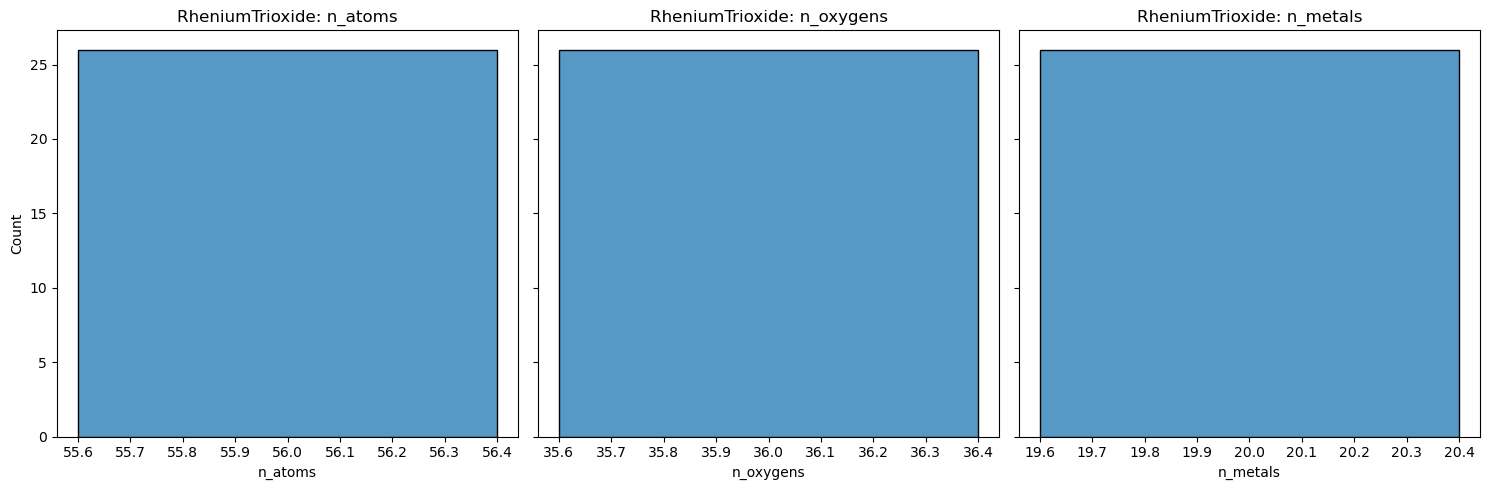

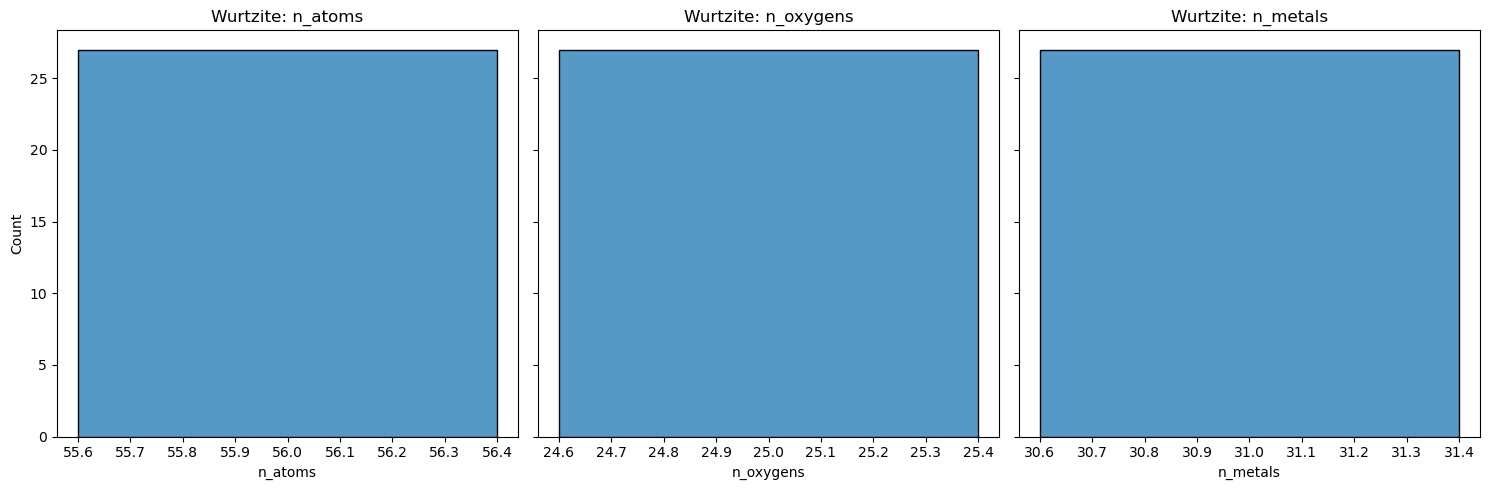

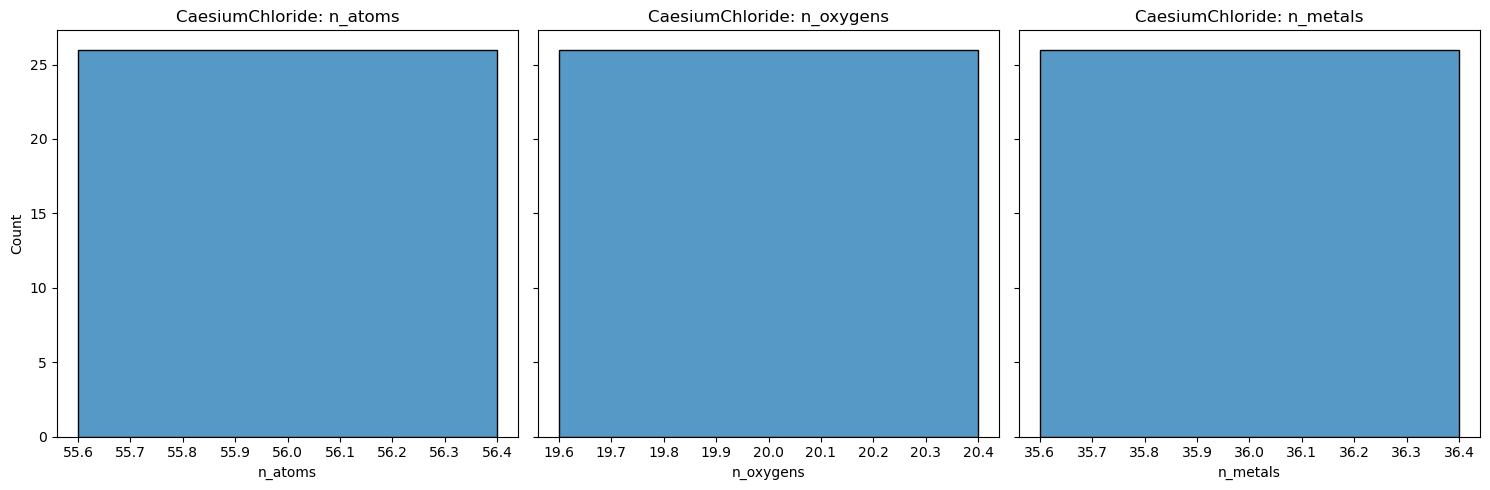

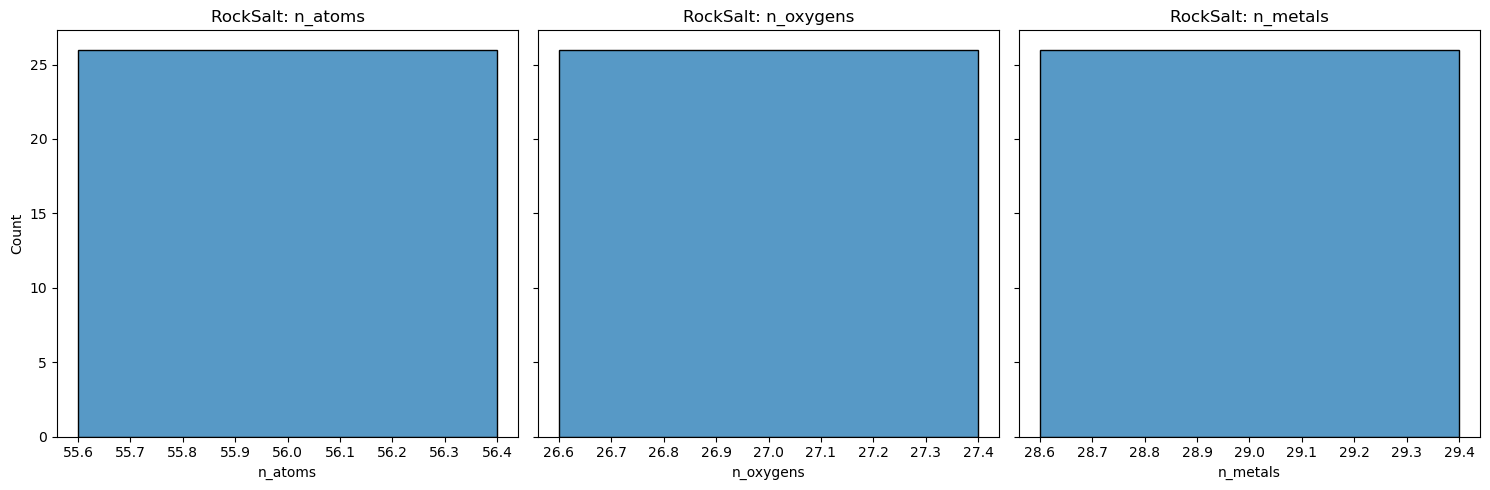

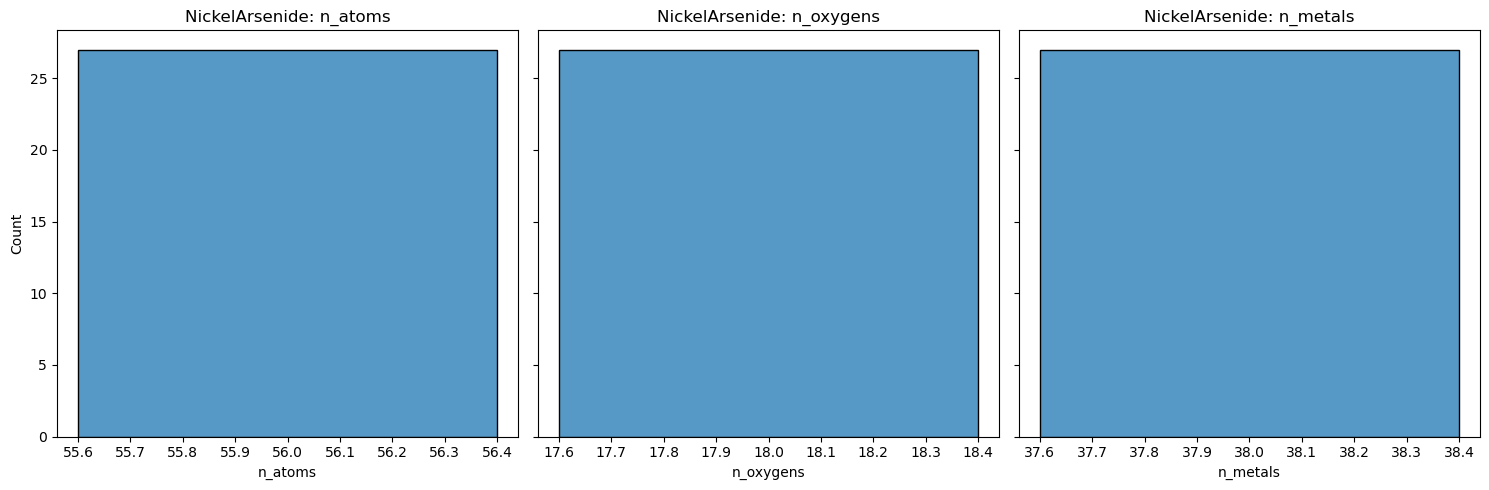

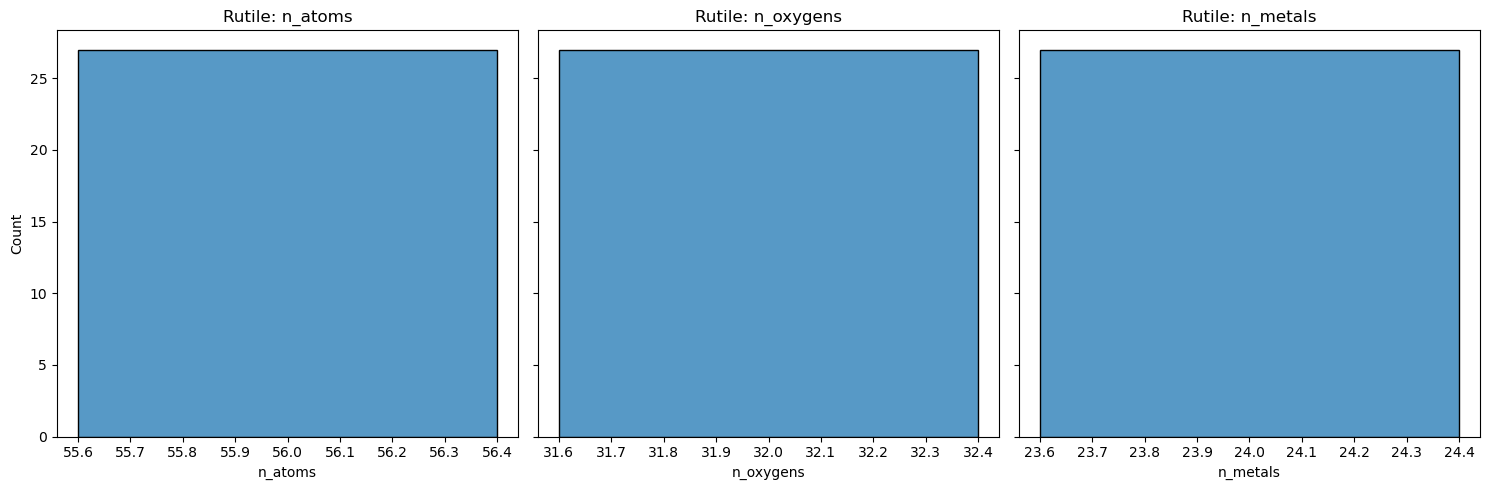

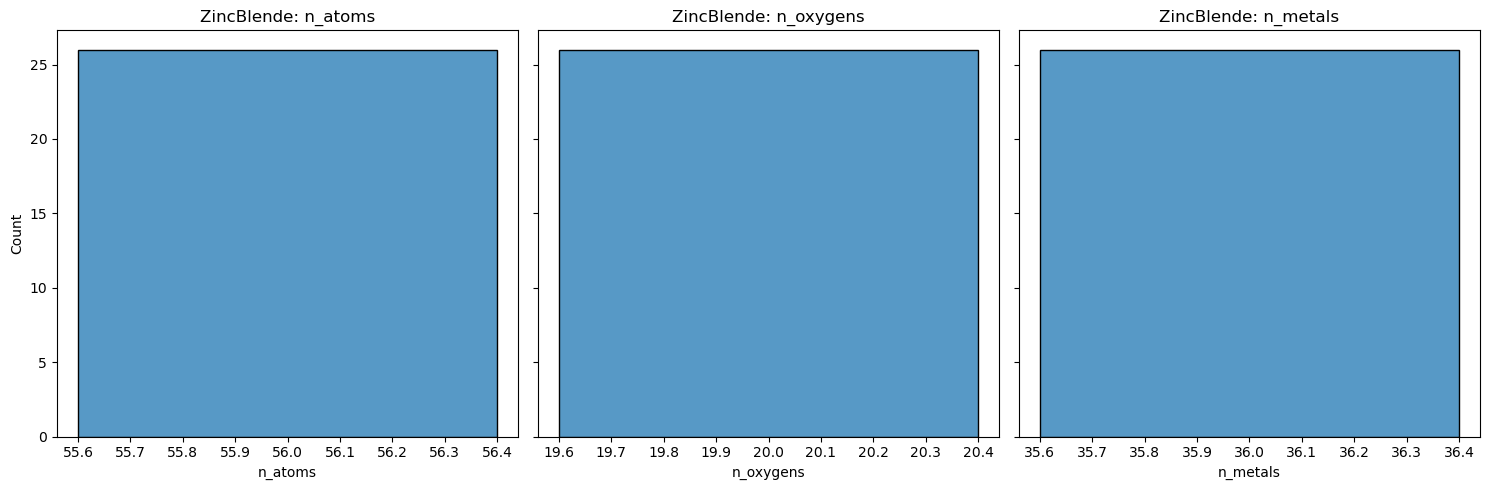

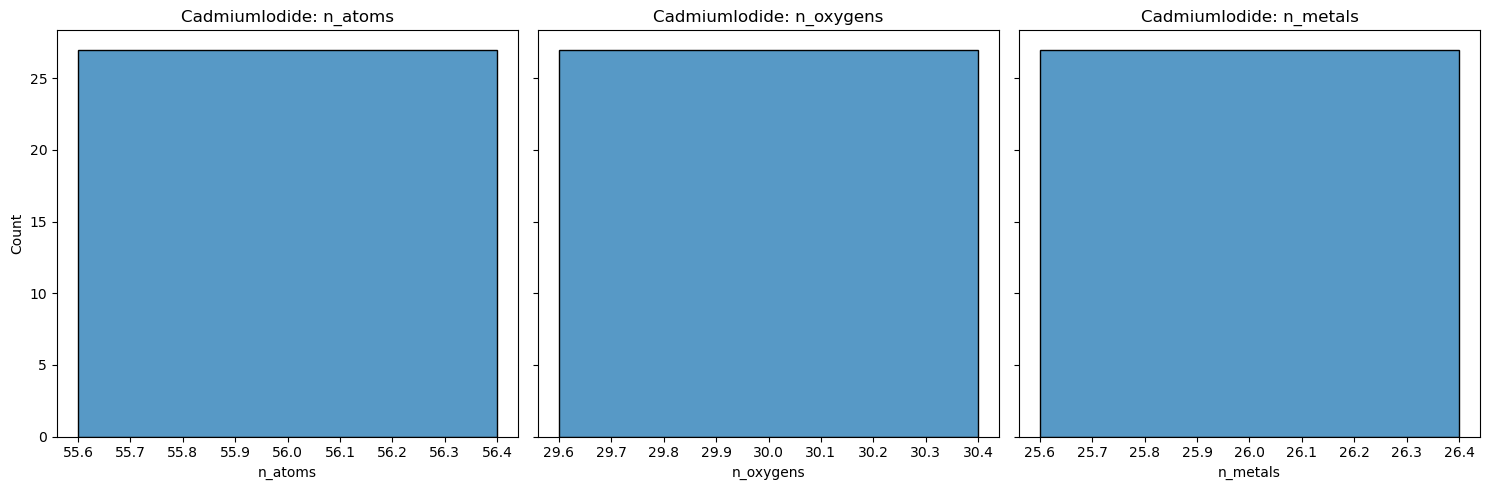

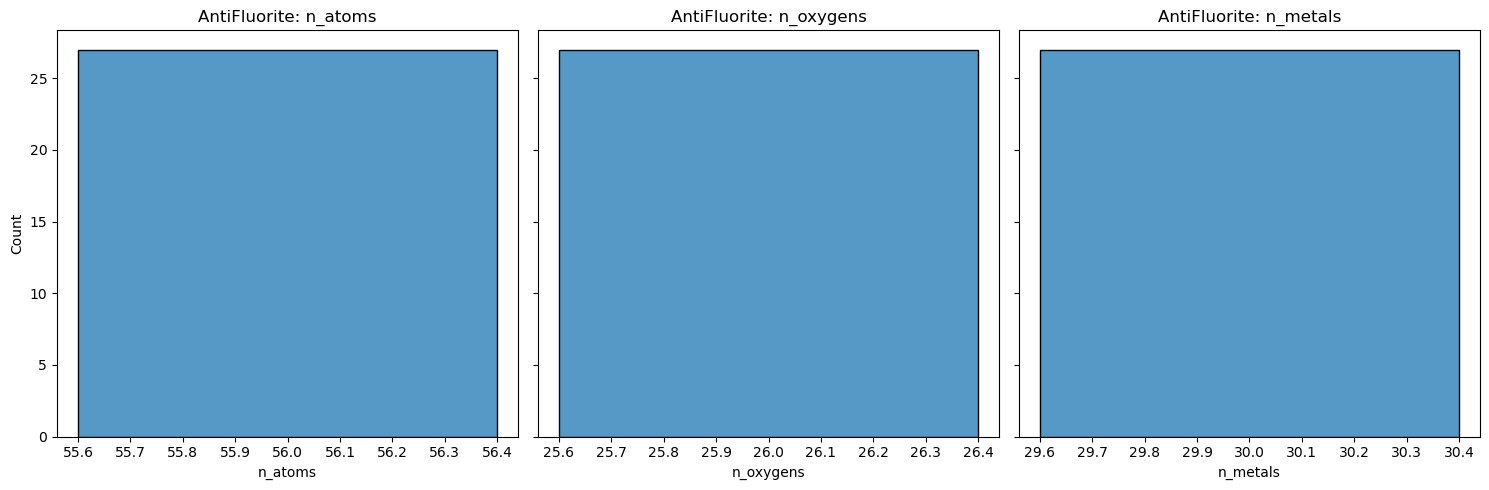

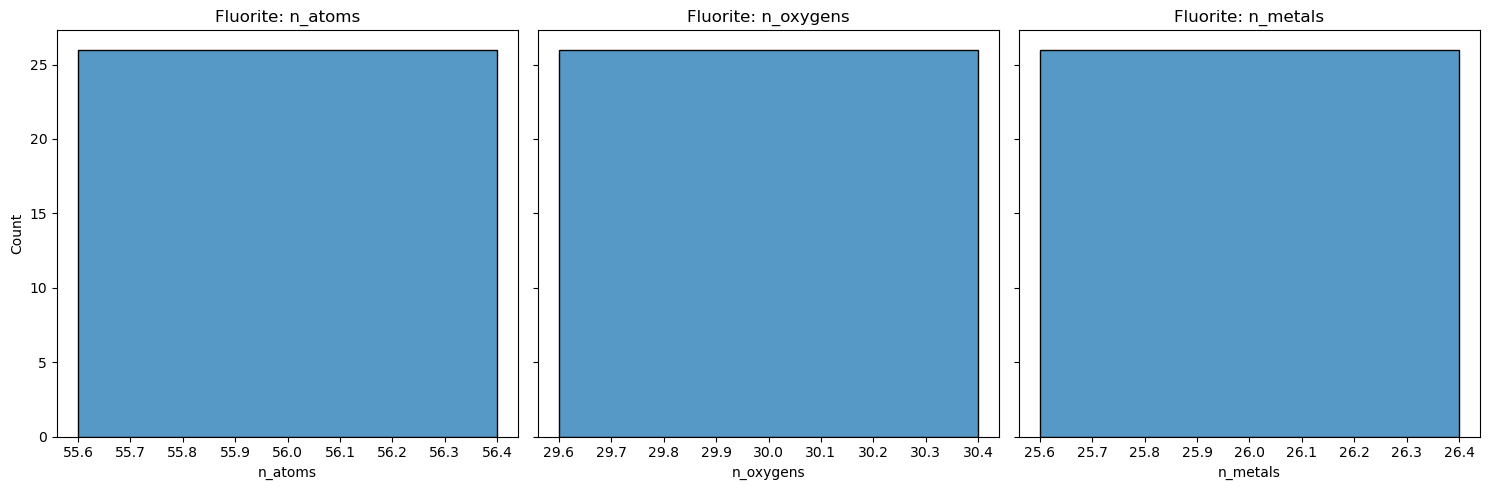

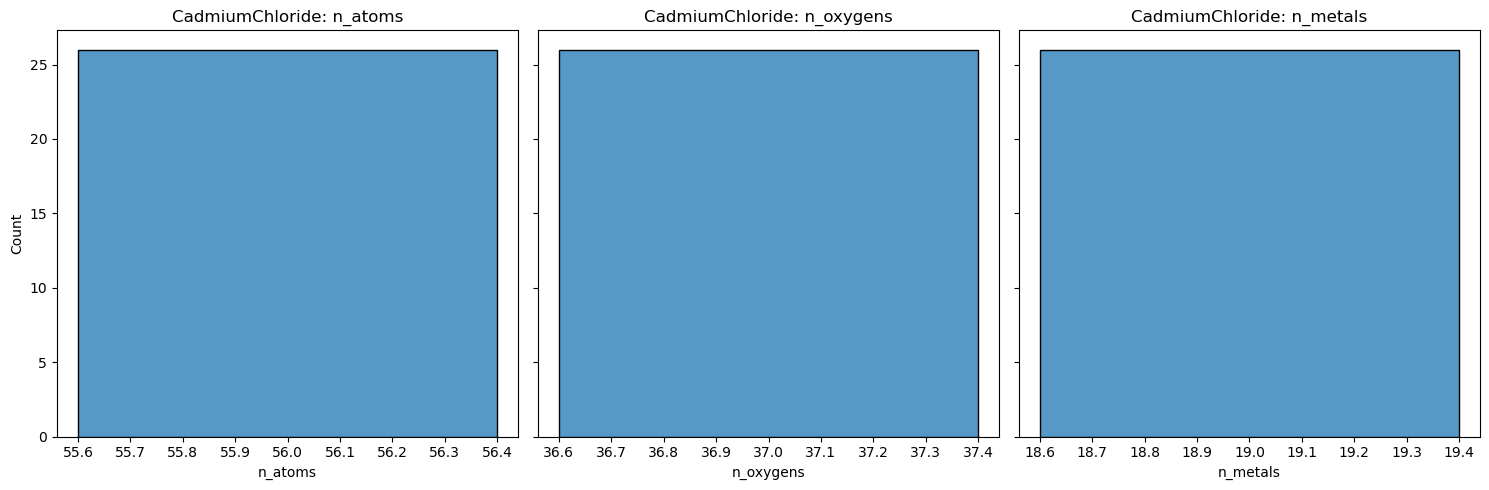

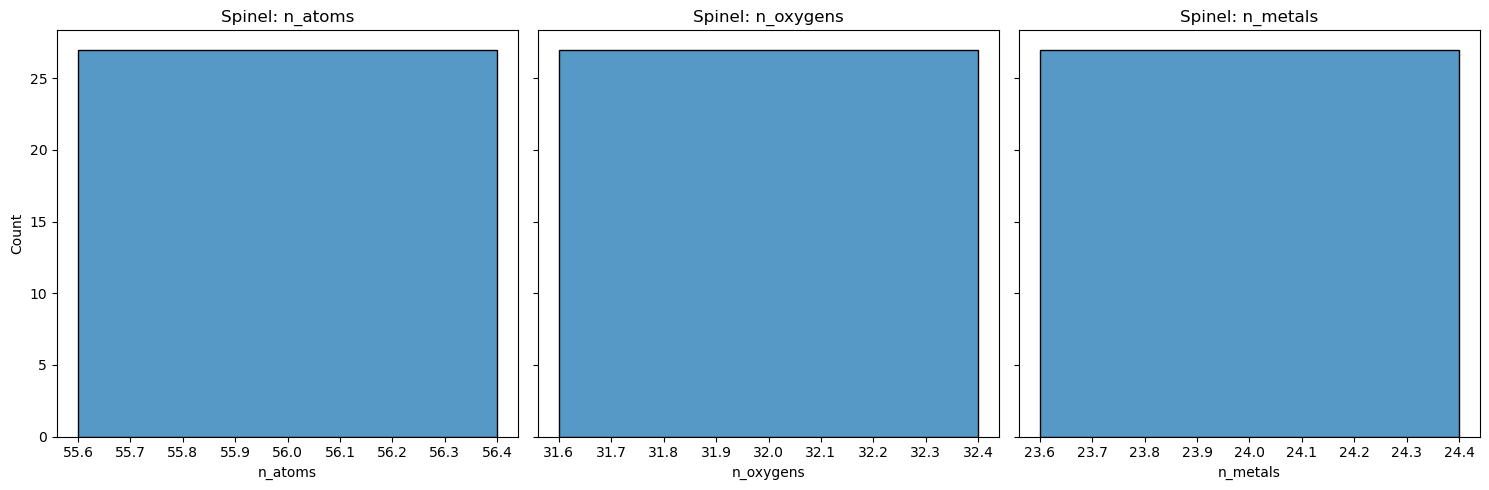

In [35]:
# Plot histogram of n_atoms, n_oxygens and n_metals for each crystalType
for crystal_type in df_rec['crystalType'].unique():
    fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
    sns.histplot(data=df_combined[df_combined['crystalType'] == crystal_type], x='n_atoms', ax=ax[0], discrete=True, shrink=0.8)
    ax[0].set_title(f'{crystal_type}: n_atoms')
    sns.histplot(data=df_combined[df_combined['crystalType'] == crystal_type], x='n_oxygens', ax=ax[1], discrete=True, shrink=0.8)
    ax[1].set_title(f'{crystal_type}: n_oxygens')
    sns.histplot(data=df_combined[df_combined['crystalType'] == crystal_type], x='n_metals', ax=ax[2], discrete=True, shrink=0.8)
    ax[2].set_title(f'{crystal_type}: n_metals')
    plt.tight_layout()
    plt.show()

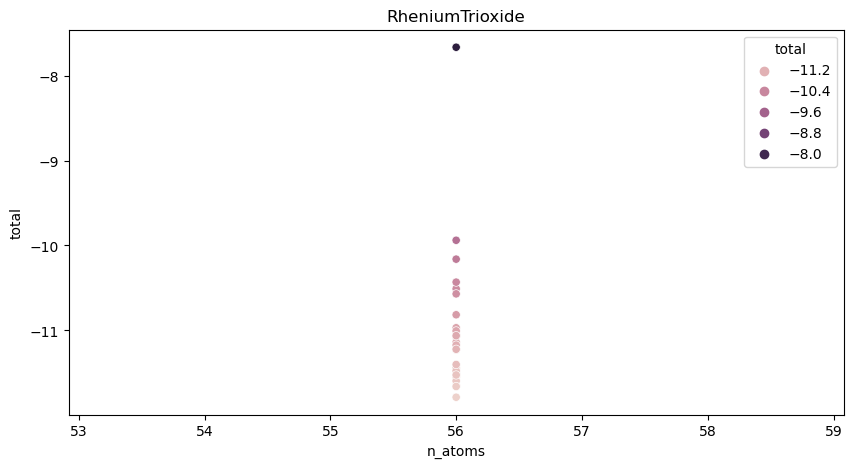

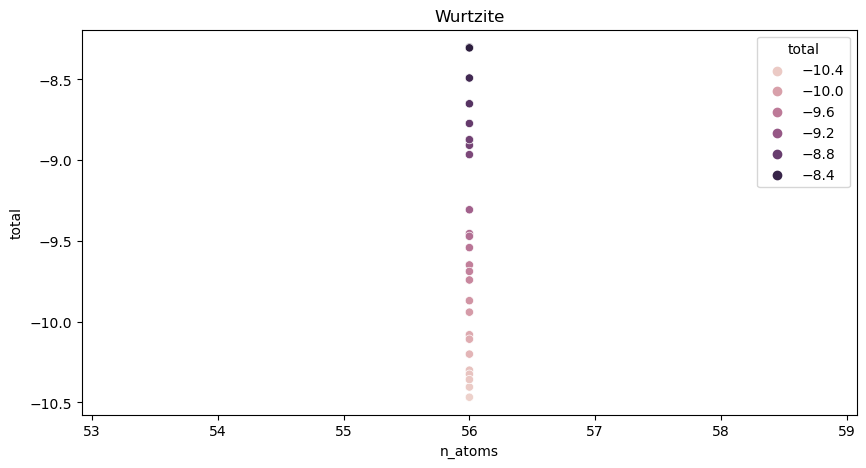

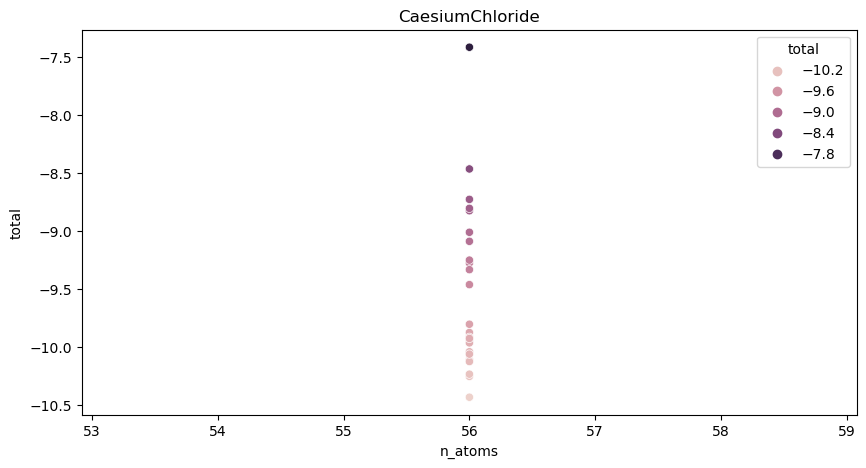

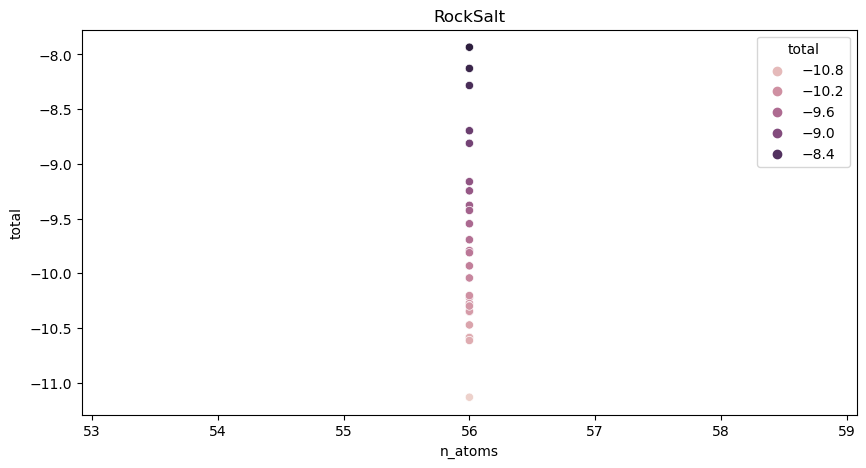

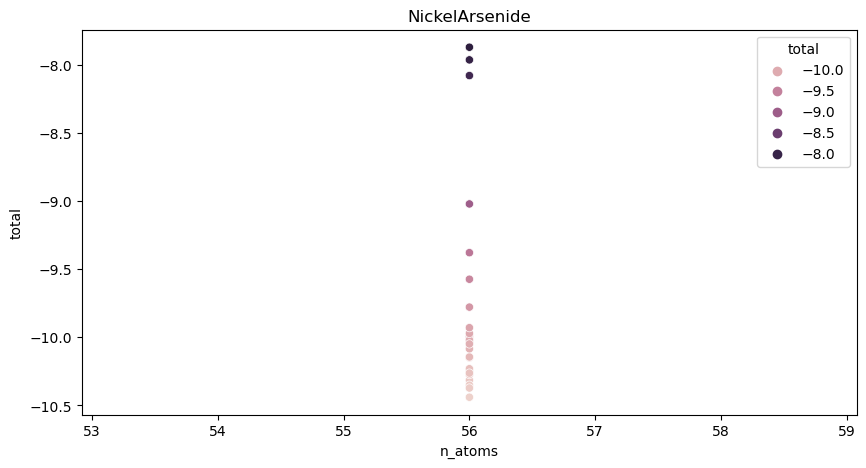

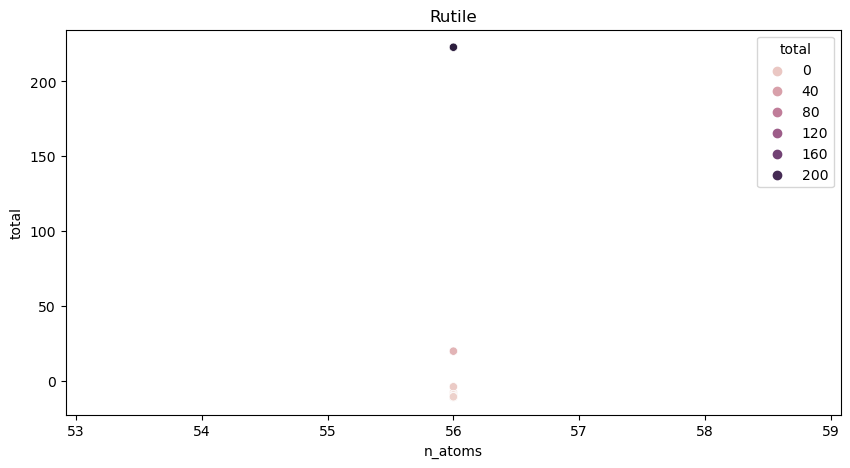

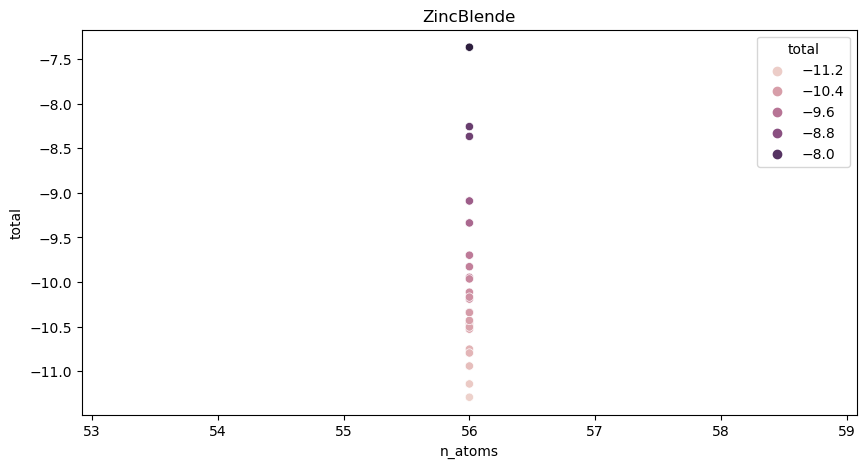

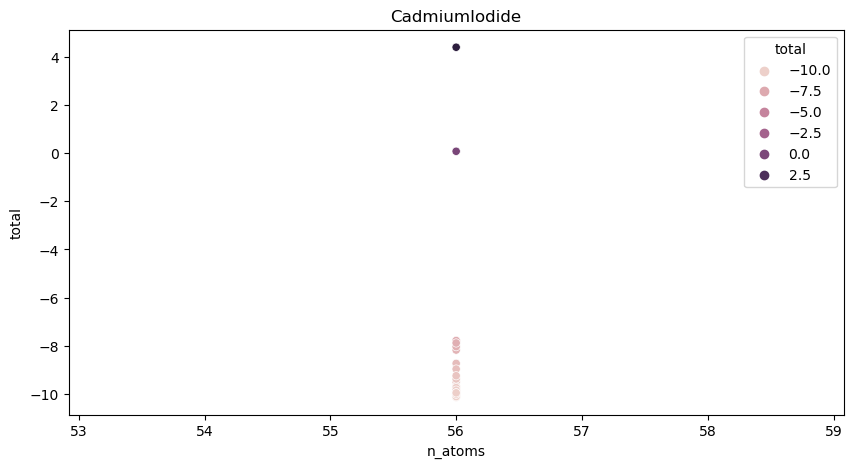

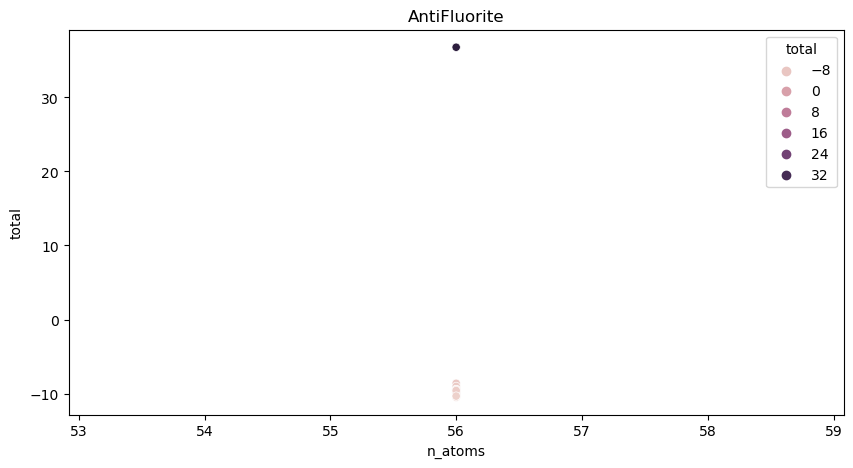

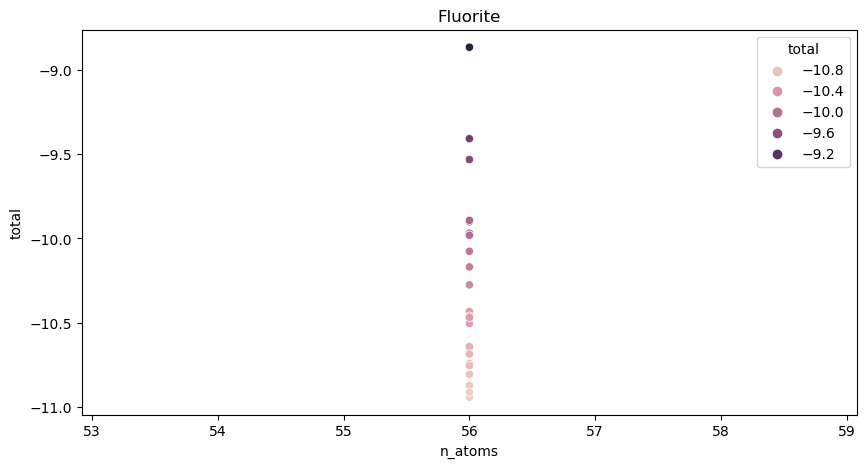

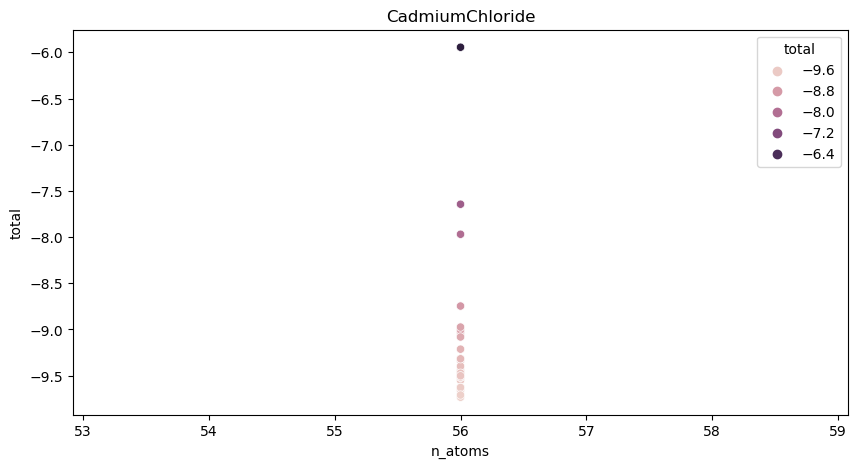

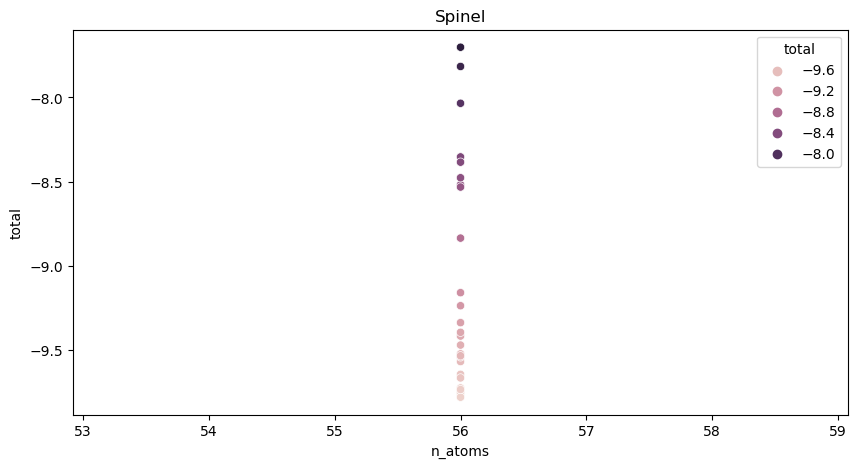

In [36]:
# Plot 2d scatter plot of n_atoms vs total loss for each crystalType
for crystal_type in df_rec['crystalType'].unique():
    plt.figure(figsize=(10, 5))
    sns.scatterplot(data=df_combined[df_combined['crystalType'] == crystal_type], x='n_atoms', y='total', hue='total')
    plt.title(f'{crystal_type}')
    plt.show()

In [37]:
import plotly.express as px
import plotly.graph_objects as go

In [39]:
# Plot 3d scatter plot of latent_space_mean from the df_rec dataframe. Each crystalType is represented by a different color and marker type
df_latent = df_rec[['latent_space_mean', 'crystalType', 'n_atoms']]
df_latent['np_size'] = df_loss['particleSize']
latent_space_array = np.array(df_latent['latent_space_mean'].tolist())
# df_latent[['ls_x', 'ls_y', 'ls_z']] = pd.DataFrame(latent_space_array, index=df_latent.index)
df_latent[['ls_x_cell', 'ls_y_cell', 'ls_z_cell', 'ls_x_content', 'ls_y_content', 'ls_z_content']] = pd.DataFrame(latent_space_array, index=df_latent.index)
df_latent['loss'] = df_loss['total']

# fig = px.scatter_3d(df_latent, x='ls_x', y='ls_y', z='ls_z', color='crystalType', symbol='crystalType', hover_name='crystalType', hover_data=['loss', 'ls_x', 'ls_y', 'ls_z', 'np_size', 'n_atoms'], color_discrete_sequence=px.colors.qualitative.Dark24)
fig = px.scatter_3d(df_latent, x='ls_x_cell', y='ls_y_cell', z='ls_z_cell', color='crystalType', symbol='crystalType', hover_name='crystalType', hover_data=['loss', 'ls_x_cell', 'ls_y_cell', 'ls_z_cell'], color_discrete_sequence=px.colors.qualitative.Dark24)
# fig = px.scatter_3d(df_latent, x='ls_x_content', y='ls_y_content', z='ls_z_content', color='crystalType', symbol='crystalType', hover_name='crystalType', hover_data=['loss', 'ls_x_content', 'ls_y_content', 'ls_z_content'], color_discrete_sequence=px.colors.qualitative.Dark24)
# fig.update_traces(marker=dict(size=3))
fig.show()
# Save the plot as a html file
# fig.write_html(f'{parent_dir}/{experiment_name}/{json_folder}/latent_space.html')
fig.write_html(f'{parent_dir}/{experiment_name}/{json_folder}/latent_space_cell.html')
# fig.write_html(f'{parent_dir}/{experiment_name}/{json_folder}/latent_space_content.html')